In [26]:
import cv2
import os
import matplotlib.pyplot as plt

In [27]:
os.makedirs("dataset/images", exist_ok=True)


In [28]:
image_folder = "dataset/images"

image_files = os.listdir(image_folder)

print(image_files)

['download (3).jpg', 'download (4).jpg', 'download (2).jpg']


In [29]:
images = []

for file in image_files:

    path = os.path.join(image_folder, file)

    img = cv2.imread(path)

    images.append(img)

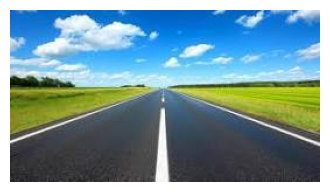

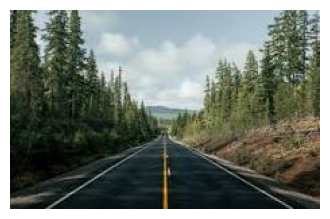

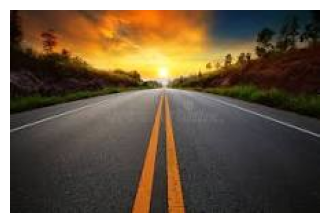

In [30]:
for img in images:

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.axis("off")

In [31]:
import json

annotation = {
 "annotations":[
   {"label":"Car","bbox":[20,150,120,80]},
   {"label":"Person","bbox":[40,160,50,100]},
   {"label":"Bike","bbox":[55,170,80,60]},
   {"label":"Truck","bbox":[80,200,140,90]}
 ]
}

with open("labels.json","w") as f:
    json.dump(annotation,f)

In [32]:
import json

with open("labels.json") as f:
    data = json.load(f)

In [45]:
objects = data["annotations"]

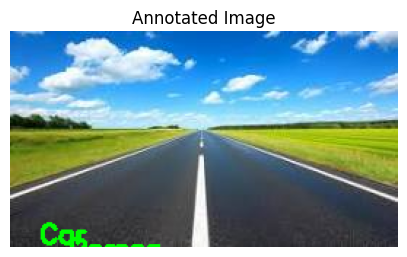

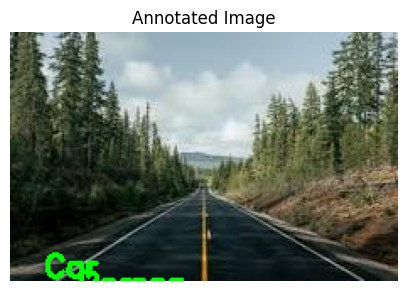

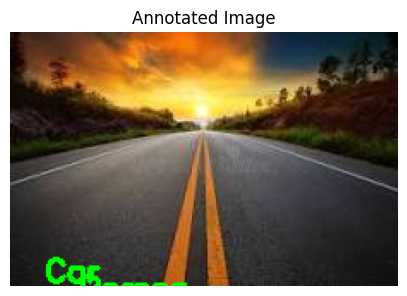

In [49]:
for img in images:
  img_box=img.copy()
  for obj in objects:
      label = obj["label"]
      x,y,w,h = obj["bbox"]
      cv2.rectangle(img_box,(x,y),(x+w,y+h),(0,0,255),2)
      cv2.putText(img_box,label,(x,y-5),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)
  img_box = cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(5,5))
  plt.imshow(img_box)
  plt.axis("off")
  plt.title("Annotated Image")

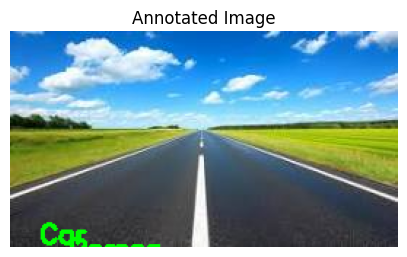

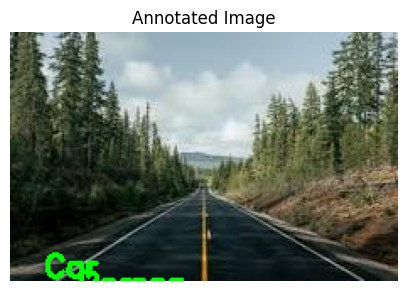

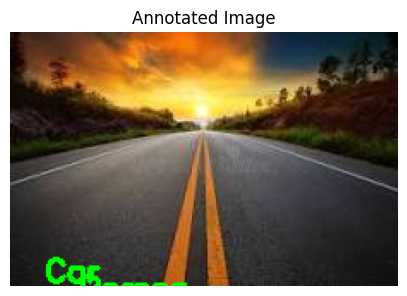

In [43]:
import cv2
import os
import matplotlib.pyplot as plt
import json

# dataset folder
image_folder = "dataset/images"

# list all images
image_files = os.listdir(image_folder)

images = []

# load images
for file in image_files:
    path = os.path.join(image_folder, file)
    img = cv2.imread(path)

    if img is not None:
        images.append(img)

# create annotation file
annotation = {
 "annotations":[
   {"label":"Car","bbox":[20,150,120,80]},
   {"label":"Person","bbox":[40,160,50,100]},
   {"label":"Bike","bbox":[55,170,80,60]},
   {"label":"Truck","bbox":[80,200,140,90]}
 ]
}

with open("labels.json","w") as f:
    json.dump(annotation,f)

# load annotation file
with open("labels.json") as f:
    data = json.load(f)

objects = data["annotations"]

# visualize dataset
for img in images:

    img_box = img.copy()

    for obj in objects:

        label = obj["label"]
        x, y, w, h = obj["bbox"]

        # draw bounding box
        cv2.rectangle(img_box,(x,y),(x+w,y+h),(0,0,255),2)

        # draw label
        cv2.putText(img_box,label,(x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,(0,255,0),2)

    # convert BGR → RGB
    img_box = cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)

    # display image
    plt.figure(figsize=(5,5))
    plt.imshow(img_box)
    plt.axis("off")
    plt.title("Annotated Image")